# import Libraries

In [45]:
# ============================================================
# SECTION 1 - INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install faker tqdm

In [46]:
# ============================================================
# SECTION 2 - IMPORT LIBRARIES
# ============================================================

import random
import uuid
import sqlite3
import ipaddress

from datetime import datetime, timedelta

import numpy as np
import pandas as pd

from faker import Faker
from tqdm import tqdm

fake = Faker()

random.seed(42)
np.random.seed(42)
Faker.seed(42)

In [47]:
# ============================================================
# SECTION 3 - PROJECT CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Project Settings
# ------------------------------------------------------------
CONFIG = {

    # Dataset Settings
    "TOTAL_RECORDS": 100000,
    "START_DATE": "2026-01-01",
    "END_DATE": "2026-03-31",

    # Users
    "NUM_USERS": 2500,
    "NUM_ATTACKERS": 80,

    # User Activity Distribution (%)
    "LOW_ACTIVITY_PERCENT": 60,
    "MEDIUM_ACTIVITY_PERCENT": 30,
    "HIGH_ACTIVITY_PERCENT": 10,

    # Traffic Distribution (%)
    "NORMAL_TRAFFIC_PERCENT": 92,
    "BRUTE_FORCE_PERCENT": 3,
    "SQLI_PERCENT": 2,
    "DIRECTORY_TRAVERSAL_PERCENT": 1,
    "PORT_SCAN_PERCENT": 1,
    "BOT_PERCENT": 0.5,
    "ENUMERATION_PERCENT": 0.5
}

# ------------------------------------------------------------
# HTTP Methods
# ------------------------------------------------------------
HTTP_METHODS = {
    "GET": 65,
    "POST": 30,
    "PUT": 3,
    "DELETE": 2
}

# ------------------------------------------------------------
# HTTP Status Codes
# ------------------------------------------------------------
STATUS_CODES = {
    200: 75,
    201: 2,
    301: 3,
    302: 2,
    400: 2,
    401: 3,
    403: 3,
    404: 7,
    429: 1,
    500: 1,
    503: 1
}

# ------------------------------------------------------------
# Website Endpoints
# ------------------------------------------------------------
NORMAL_ENDPOINTS = [
    "/",
    "/home",
    "/products",
    "/search",
    "/contact",
    "/about",
    "/blog",
    "/cart",
    "/checkout",
    "/profile",
    "/login",
    "/logout",
    "/register",
    "/api/products",
    "/api/orders"
]

ADMIN_ENDPOINTS = [
    "/admin",
    "/admin/login",
    "/dashboard",
    "/admin/users"
]

SENSITIVE_ENDPOINTS = [
    "/.env",
    "/config",
    "/backup",
    "/server-status",
    "/phpmyadmin",
    "/.git"
]

# ------------------------------------------------------------
# Browser User Agents
# ------------------------------------------------------------
BROWSERS = [
    "Chrome 138.0 (Windows 11)",
    "Firefox 140.0 (Ubuntu)",
    "Edge 138.0 (Windows 11)",
    "Safari 18.0 (macOS)",
    "Chrome Mobile (Android)"
]

NORMAL_AGENTS = BROWSERS.copy()

ATTACK_AGENTS = [
    "curl",
    "wget",
    "python-requests",
    "sqlmap",
    "Nmap",
    "Nikto"
]

# ------------------------------------------------------------
# Attack Categories
# ------------------------------------------------------------
ATTACK_TYPES = [
    "Normal",
    "Brute Force",
    "SQL Injection",
    "Directory Traversal",
    "Port Scan",
    "404 Enumeration"
]

# ------------------------------------------------------------
# Geographic Locations
# ------------------------------------------------------------
COUNTRIES = {
    "Kenya": ["Nairobi", "Mombasa"],
    "Ethiopia": ["Addis Ababa", "Mekelle"],
    "Uganda": ["Kampala"],
    "Tanzania": ["Dar es Salaam"],
    "United States": ["New York", "Dallas"],
    "United Kingdom": ["London"],
    "Germany": ["Berlin"],
    "India": ["Mumbai"],
    "Singapore": ["Singapore"]
}

# ------------------------------------------------------------
# User Roles
# ------------------------------------------------------------
USER_ROLES = {
    "Visitor": 55,
    "Customer": 35,
    "Administrator": 5,
    "API Client": 5
}

# ------------------------------------------------------------
# Behaviour Profiles
# ------------------------------------------------------------
BEHAVIOUR_PROFILES = {
    "Casual Visitor": 40,
    "Shopper": 30,
    "Registered User": 20,
    "Administrator": 5,
    "API Client": 5
}

# ------------------------------------------------------------
# Requests Per Session
# ------------------------------------------------------------
PROFILE_CONFIG = {
    "Casual Visitor": {"min": 3, "max": 5},
    "Shopper": {"min": 8, "max": 15},
    "Registered User": {"min": 6, "max": 10},
    "Administrator": {"min": 5, "max": 12},
    "API Client": {"min": 10, "max": 20}
}

# ------------------------------------------------------------
# User Activity Levels
# (min_sessions, max_sessions)
# ------------------------------------------------------------
ACTIVITY_LEVELS = {
    "Low": (2, 5),
    "Medium": (6, 12),
    "High": (13, 25)
}

In [48]:
# ============================================================
# SECTION 4 - UTILITY FUNCTIONS
# ============================================================

# -------------------------------
# Weighted Random Selection
# -------------------------------
def weighted_choice(options_dict):
    """Return one value based on weighted probabilities."""
    return random.choices(
        population=list(options_dict.keys()),
        weights=list(options_dict.values()),
        k=1
    )[0]


# -------------------------------
# Session ID Generator
# -------------------------------
def generate_session_id():
    """Generate a unique session ID."""
    return str(uuid.uuid4())


# -------------------------------
# Public IP Address Generator
# -------------------------------
def generate_public_ip():
    """Generate a random IPv4 address."""
    return str(ipaddress.IPv4Address(random.randint(1, 2**32 - 1)))


# -------------------------------
# Random Location Generator
# -------------------------------
def generate_location():
    """Return a random country and city."""
    country = random.choice(list(COUNTRIES.keys()))
    city = random.choice(COUNTRIES[country])
    return country, city


# -------------------------------
# Random Timestamp Generator
# -------------------------------
def generate_timestamp():
    """Generate a random timestamp within the project period."""

    start = datetime.strptime(
        CONFIG["START_DATE"],
        "%Y-%m-%d"
    )

    end = datetime.strptime(
        CONFIG["END_DATE"],
        "%Y-%m-%d"
    )

    seconds = random.randint(
        0,
        int((end - start).total_seconds())
    )

    return start + timedelta(seconds=seconds)


# -------------------------------
# HTTP Method Generator
# -------------------------------
def generate_method():
    """Generate an HTTP method using configured probabilities."""
    return weighted_choice(HTTP_METHODS)


# -------------------------------
# HTTP Status Code Generator
# -------------------------------
def generate_status():
    """Generate an HTTP status code using configured probabilities."""
    return weighted_choice(STATUS_CODES)


# -------------------------------
# Response Size Generator
# -------------------------------
def generate_response_size():
    """Generate a realistic response size (bytes)."""
    return random.randint(1024, 500000)


# -------------------------------
# Response Time Generator
# -------------------------------
def generate_response_time():
    """Generate a realistic response time (milliseconds)."""
    return random.randint(20, 1200)


# -------------------------------
# User Activity Level
# -------------------------------
def assign_activity_level():
    """Assign a user activity level."""
    return random.choices(
        ["Low", "Medium", "High"],
        weights=[60, 30, 10],
        k=1
    )[0]


# -------------------------------
# User Agent Generator
# -------------------------------
def generate_user_agent(attacker=False):
    """Return a normal or attacker user agent."""
    if attacker:
        return random.choice(ATTACK_AGENTS)
    return random.choice(NORMAL_AGENTS)

In [49]:
# ============================================================
# SECTION 5 - USER POOL GENERATOR
# ============================================================

In [50]:
USER_ROLES = {
    "Visitor": 55,
    "Customer": 35,
    "Administrator": 5,
    "API Client": 5
}

In [51]:
BEHAVIOUR_PROFILES = {
    "Casual Visitor": 40,
    "Shopper": 30,
    "Registered User": 20,
    "Administrator": 5,
    "API Client": 5
}

In [52]:
BROWSERS = [
    "Chrome 138.0 (Windows 11)",
    "Firefox 140.0 (Ubuntu)",
    "Edge 138.0 (Windows 11)",
    "Safari 18.0 (macOS)",
    "Chrome Mobile (Android)"
]

Helper Function

In [53]:
def weighted_choice(options_dict):
    """
    Select one value using weighted probabilities.
    """

    return random.choices(
        population=list(options_dict.keys()),
        weights=list(options_dict.values()),
        k=1
    )[0]

In [54]:
def generate_user_pool(config):

    users = []

    for user_id in range(1, config["NUM_USERS"] + 1):

        country, city = generate_location()

        user = {

            "user_id": user_id,

            "username": f"user_{user_id:04d}",

            "role": weighted_choice(USER_ROLES),

            "country": country,

            "city": city,

            "browser": random.choice(BROWSERS),

            "behaviour_profile": weighted_choice(BEHAVIOUR_PROFILES),

            "account_created": fake.date_between(
                start_date="-3y",
                end_date="-30d"
            ),

            "active": random.choices(
                [True, False],
                weights=[95, 5],
                k=1
            )[0]

        }

        users.append(user)

    return pd.DataFrame(users)

Generate the User Pool

In [55]:
users_df = generate_user_pool(CONFIG)
print(users_df.shape)
users_df.head()

(2500, 9)


,user_id,username,role,country,city,browser,behaviour_profile,account_created,active
0,1,user_0001,Customer,Ethiopia,Addis Ababa,Firefox 140.0 (Ubuntu),Casual Visitor,2025-06-07,True
1,2,user_0002,Customer,Singapore,Singapore,Chrome 138.0 (Windows 11),Casual Visitor,2023-08-22,True
2,3,user_0003,Customer,Singapore,Singapore,Chrome Mobile (Android),Shopper,2024-05-15,True
3,4,user_0004,Customer,United States,New York,Firefox 140.0 (Ubuntu),Shopper,2024-03-20,True
4,5,user_0005,API Client,Uganda,Kampala,Edge 138.0 (Windows 11),Casual Visitor,2025-09-19,True


In [56]:
print("=" * 60)
print("USER POOL VALIDATION")
print("=" * 60)

print(f"Total Users: {len(users_df):,}")

print("\nRole Distribution")
print(users_df["role"].value_counts())

print("\nBehaviour Profiles")
print(users_df["behaviour_profile"].value_counts())

print("\nCountries")
print(users_df["country"].value_counts())

print("\nBrowsers")
print(users_df["browser"].value_counts())

print("\nActive Accounts")
print(users_df["active"].value_counts())

USER POOL VALIDATION
Total Users: 2,500

Role Distribution
role
Visitor          1397
Customer          845
API Client        135
Administrator     123
Name: count, dtype: int64

Behaviour Profiles
behaviour_profile
Casual Visitor     1024
Shopper             765
Registered User     458
API Client          128
Administrator       125
Name: count, dtype: int64

Countries
country
India             300
Germany           294
Ethiopia          293
United States     281
Tanzania          269
Singapore         268
Uganda            268
Kenya             264
United Kingdom    263
Name: count, dtype: int64

Browsers
browser
Safari 18.0 (macOS)          528
Edge 138.0 (Windows 11)      513
Firefox 140.0 (Ubuntu)       508
Chrome Mobile (Android)      487
Chrome 138.0 (Windows 11)    464
Name: count, dtype: int64

Active Accounts
active
True     2367
False     133
Name: count, dtype: int64


In [57]:
users_df.to_csv(
    "users_pool.csv",
    index=False
)

print("User pool saved successfully.")

User pool saved successfully.


In [58]:
# ============================================================
# SECTION 6 - SESSION GENERATOR (FINAL VERSION)
# ============================================================

ACTIVITY_LEVELS = {
    "Low": (2, 5, 60),       # 60% of users
    "Medium": (6, 12, 30),   # 30%
    "High": (13, 25, 10)     # 10%
}

def assign_activity_level():
    return random.choices(
        ["Low", "Medium", "High"],
        weights=[60, 30, 10],
        k=1
    )[0]

PROFILE_CONFIG = {
    "Casual Visitor": {"min": 3, "max": 5},
    "Shopper": {"min": 8, "max": 15},
    "Registered User": {"min": 6, "max": 10},
    "Administrator": {"min": 5, "max": 12},
    "API Client": {"min": 10, "max": 20}
}

def generate_session(user):

    profile = user["behaviour_profile"]

    cfg = PROFILE_CONFIG[profile]

    return {
        "session_id": generate_session_id(),
        "user_id": user["user_id"],
        "username": user["username"],
        "role": user["role"],
        "country": user["country"],
        "city": user["city"],
        "browser": user["browser"],
        "ip_address": generate_public_ip(),
        "start_time": generate_timestamp(),
        "num_requests": random.randint(cfg["min"], cfg["max"]),
        "behaviour_profile": profile
    }

sessions = []

for _, user in users_df.iterrows():

    activity = assign_activity_level()

    min_s, max_s, _ = ACTIVITY_LEVELS[activity]

    total_sessions = random.randint(min_s, max_s)

    for _ in range(total_sessions):
        sessions.append(generate_session(user))

sessions_df = pd.DataFrame(sessions)

print("="*60)
print("SESSION SUMMARY")
print("="*60)

print(f"Users           : {len(users_df):,}")
print(f"Sessions        : {len(sessions_df):,}")
print(f"Average/User    : {len(sessions_df)/len(users_df):.2f}")

sessions_df.head()

SESSION SUMMARY
Users           : 2,500
Sessions        : 16,959
Average/User    : 6.78


,session_id,user_id,username,role,country,city,browser,ip_address,start_time,num_requests,behaviour_profile
0,47e44784-b469-458d-a93f-0ff629cc3697,1,user_0001,Customer,Ethiopia,Addis Ababa,Firefox 140.0 (Ubuntu),232.4.140.146,2026-02-23 15:06:28,5,Casual Visitor
1,a69caff1-4e69-40f5-b574-d983fac6e291,1,user_0001,Customer,Ethiopia,Addis Ababa,Firefox 140.0 (Ubuntu),76.43.250.151,2026-01-10 18:01:55,4,Casual Visitor
2,560186fe-aeea-462a-8bb6-3687d4d6776e,1,user_0001,Customer,Ethiopia,Addis Ababa,Firefox 140.0 (Ubuntu),192.150.219.229,2026-01-04 22:55:30,4,Casual Visitor
3,309215a4-8cd6-49e0-9817-52c636ffccd1,1,user_0001,Customer,Ethiopia,Addis Ababa,Firefox 140.0 (Ubuntu),235.56.252.224,2026-03-27 05:48:18,4,Casual Visitor
4,2a26812e-5ea6-4b98-9e5b-228536afd932,2,user_0002,Customer,Singapore,Singapore,Chrome 138.0 (Windows 11),68.224.87.136,2026-03-13 22:52:29,3,Casual Visitor


In [59]:
# ============================================================
# SECTION 7 - REQUEST GENERATOR
# ============================================================

PROFILE_ENDPOINTS = {
    "Casual Visitor": [
        "/", "/home", "/about", "/contact", "/blog"
    ],
    "Shopper": [
        "/", "/products", "/search", "/cart",
        "/checkout", "/profile"
    ],
    "Registered User": [
        "/login", "/profile", "/api/orders",
        "/logout", "/products"
    ],
    "Administrator": [
        "/admin/login", "/dashboard",
        "/admin/users", "/server-status"
    ],
    "API Client": [
        "/api/products",
        "/api/orders"
    ]
}

logs = []
log_id = 1

for _, session in sessions_df.iterrows():

    current_time = session["start_time"]

    endpoints = PROFILE_ENDPOINTS[
        session["behaviour_profile"]
    ]

    for _ in range(session["num_requests"]):

        endpoint = random.choice(endpoints)

        log = {

            "log_id": log_id,

            "timestamp": current_time,

            "session_id": session["session_id"],

            "user_id": session["user_id"],

            "username": session["username"],

            "ip_address": session["ip_address"],

            "country": session["country"],

            "city": session["city"],

            "method": generate_method(),

            "endpoint": endpoint,

            "protocol": "HTTP/1.1",

            "status_code": generate_status(),

            "response_size": generate_response_size(),

            "response_time_ms": generate_response_time(),

            "user_agent": session["browser"],

            "attack_type": "Normal",

            "is_suspicious": False

        }

        logs.append(log)

        log_id += 1

        current_time += timedelta(
            seconds=random.randint(2,20)
        )

logs_df = pd.DataFrame(logs)

print(f"Generated {len(logs_df):,} log records")

logs_df.head()

Generated 132,237 log records


,log_id,timestamp,session_id,user_id,username,ip_address,country,city,method,endpoint,protocol,status_code,response_size,response_time_ms,user_agent,attack_type,is_suspicious
0,1,2026-02-23 15:06:28,47e44784-b469-458d-a93f-0ff629cc3697,1,user_0001,232.4.140.146,Ethiopia,Addis Ababa,GET,/home,HTTP/1.1,200,489499,744,Firefox 140.0 (Ubuntu),Normal,False
1,2,2026-02-23 15:06:38,47e44784-b469-458d-a93f-0ff629cc3697,1,user_0001,232.4.140.146,Ethiopia,Addis Ababa,GET,/home,HTTP/1.1,200,467330,1005,Firefox 140.0 (Ubuntu),Normal,False
2,3,2026-02-23 15:06:47,47e44784-b469-458d-a93f-0ff629cc3697,1,user_0001,232.4.140.146,Ethiopia,Addis Ababa,POST,/,HTTP/1.1,200,283123,376,Firefox 140.0 (Ubuntu),Normal,False
3,4,2026-02-23 15:06:51,47e44784-b469-458d-a93f-0ff629cc3697,1,user_0001,232.4.140.146,Ethiopia,Addis Ababa,GET,/blog,HTTP/1.1,200,400559,718,Firefox 140.0 (Ubuntu),Normal,False
4,5,2026-02-23 15:07:06,47e44784-b469-458d-a93f-0ff629cc3697,1,user_0001,232.4.140.146,Ethiopia,Addis Ababa,GET,/blog,HTTP/1.1,200,49874,298,Firefox 140.0 (Ubuntu),Normal,False


In [60]:
# ============================================================
# SECTION 8 - ATTACK SESSION GENERATOR
# ============================================================

ATTACKER_IPS = [generate_public_ip() for _ in range(CONFIG["NUM_ATTACKERS"])]

ATTACK_ENDPOINTS = {
    "Brute Force": ["/login"],
    "SQL Injection": [
        "/search?q=' OR 1=1 --",
        "/login?user=admin'--",
        "/products?id=1 UNION SELECT * FROM users"
    ],
    "Directory Traversal": [
        "/../../etc/passwd",
        "/../../../windows/system32",
        "/.env",
        "/backup"
    ],
    "Port Scan": [
        "/admin",
        "/admin/login",
        "/phpmyadmin",
        "/server-status",
        "/config",
        "/.git",
        "/backup"
    ],
    "404 Enumeration": [
        "/admin_old",
        "/backup.zip",
        "/secret",
        "/test",
        "/old",
        "/unknown"
    ]
}

attack_logs = []

next_log_id = logs_df["log_id"].max() + 1

for attack_type, endpoints in ATTACK_ENDPOINTS.items():

    for _ in range(40):     # Number of attack sessions

        attacker_ip = random.choice(ATTACKER_IPS)

        session_id = generate_session_id()

        start_time = generate_timestamp()

        requests = random.randint(8,20)

        current_time = start_time

        for i in range(requests):

            endpoint = random.choice(endpoints)

            if attack_type == "Brute Force":
                status = 401 if i < requests-1 else 200
                method = "POST"
            elif attack_type == "Port Scan":
                status = 404 if random.random() < 0.6 else 403
                method = "GET"
            elif attack_type == "404 Enumeration":
                status = 404
                method = "GET"
            else:
                status = 403 if random.random() < 0.5 else 400
                method = "GET"

            attack_logs.append({

                "log_id": next_log_id,

                "timestamp": current_time,

                "session_id": session_id,

                "user_id": None,

                "username": None,

                "ip_address": attacker_ip,

                "country": "Unknown",

                "city": "Unknown",

                "method": method,

                "endpoint": endpoint,

                "protocol": "HTTP/1.1",

                "status_code": status,

                "response_size": generate_response_size(),

                "response_time_ms": generate_response_time(),

                "user_agent": random.choice(ATTACK_AGENTS),

                "attack_type": attack_type,

                "is_suspicious": True

            })

            next_log_id += 1

            current_time += timedelta(seconds=random.randint(1,5))

attack_df = pd.DataFrame(attack_logs)

print(f"Generated {len(attack_df):,} attack logs")

attack_df.head()

Generated 2,859 attack logs


,log_id,timestamp,session_id,user_id,username,ip_address,country,city,method,endpoint,protocol,status_code,response_size,response_time_ms,user_agent,attack_type,is_suspicious
0,132238,2026-01-02 20:09:08,9ab8a2d3-6c33-4dcf-a3d6-bc78112d3a3d,None,None,69.49.251.150,Unknown,Unknown,POST,/login,HTTP/1.1,401,379230,670,Nikto,Brute Force,True
1,132239,2026-01-02 20:09:09,9ab8a2d3-6c33-4dcf-a3d6-bc78112d3a3d,None,None,69.49.251.150,Unknown,Unknown,POST,/login,HTTP/1.1,401,75419,86,wget,Brute Force,True
2,132240,2026-01-02 20:09:12,9ab8a2d3-6c33-4dcf-a3d6-bc78112d3a3d,None,None,69.49.251.150,Unknown,Unknown,POST,/login,HTTP/1.1,401,224682,434,Nikto,Brute Force,True
3,132241,2026-01-02 20:09:15,9ab8a2d3-6c33-4dcf-a3d6-bc78112d3a3d,None,None,69.49.251.150,Unknown,Unknown,POST,/login,HTTP/1.1,401,394036,411,python-requests,Brute Force,True
4,132242,2026-01-02 20:09:19,9ab8a2d3-6c33-4dcf-a3d6-bc78112d3a3d,None,None,69.49.251.150,Unknown,Unknown,POST,/login,HTTP/1.1,401,214564,187,python-requests,Brute Force,True


In [61]:
# ============================================================
# SECTION 9 - BUILD FINAL DATASET
# ============================================================

# Merge normal and attack logs
final_logs = pd.concat(
    [logs_df, attack_df],
    ignore_index=True
)

# Sort chronologically
final_logs = final_logs.sort_values(
    by="timestamp"
).reset_index(drop=True)

# Reassign log IDs
final_logs["log_id"] = range(1, len(final_logs) + 1)

print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print(f"Total Records      : {len(final_logs):,}")
print(f"Normal Logs        : {(final_logs['is_suspicious']==False).sum():,}")
print(f"Attack Logs        : {(final_logs['is_suspicious']==True).sum():,}")
print(f"Unique IPs         : {final_logs['ip_address'].nunique():,}")
print(f"Unique Sessions    : {final_logs['session_id'].nunique():,}")

print("\nAttack Distribution")
print(final_logs["attack_type"].value_counts())

print("\nStatus Codes")
print(final_logs["status_code"].value_counts())

print("\nMissing Values")
print(final_logs.isnull().sum())

# Save sample dataset
final_logs.to_csv("server_logs_sample.csv", index=False)

print("\nSample dataset saved as server_logs_sample.csv")

final_logs.head()

FINAL DATASET SUMMARY
Total Records      : 135,096
Normal Logs        : 132,237
Attack Logs        : 2,859
Unique IPs         : 17,033
Unique Sessions    : 17,159

Attack Distribution
attack_type
Normal                 132237
Port Scan                 591
404 Enumeration           587
Directory Traversal       582
SQL Injection             579
Brute Force               520
Name: count, dtype: int64

Status Codes
status_code
200    99353
404    10294
403     4738
401     4387
301     3964
400     3292
201     2566
302     2558
429     1343
503     1335
500     1266
Name: count, dtype: int64

Missing Values
log_id                 0
timestamp              0
session_id             0
user_id             2859
username            2859
ip_address             0
country                0
city                   0
method                 0
endpoint               0
protocol               0
status_code            0
response_size          0
response_time_ms       0
user_agent             0
attack_type 

,log_id,timestamp,session_id,user_id,username,ip_address,country,city,method,endpoint,protocol,status_code,response_size,response_time_ms,user_agent,attack_type,is_suspicious
0,1,2026-01-01 00:08:08,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/blog,HTTP/1.1,401,133466,873,Chrome 138.0 (Windows 11),Normal,False
1,2,2026-01-01 00:08:22,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/about,HTTP/1.1,200,48932,832,Chrome 138.0 (Windows 11),Normal,False
2,3,2026-01-01 00:08:25,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,POST,/,HTTP/1.1,200,281981,368,Chrome 138.0 (Windows 11),Normal,False
3,4,2026-01-01 00:08:35,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/about,HTTP/1.1,200,412517,745,Chrome 138.0 (Windows 11),Normal,False
4,5,2026-01-01 00:08:39,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/home,HTTP/1.1,301,54265,920,Chrome 138.0 (Windows 11),Normal,False


In [62]:
# ============================================================
# SECTION 10 - DATASET VALIDATION
# ============================================================

print("="*70)
print("DATASET VALIDATION REPORT")
print("="*70)

# 1. Dataset Shape
print(f"\nDataset Shape: {final_logs.shape}")

# 2. Data Types
print("\nData Types")
print(final_logs.dtypes)

# 3. Missing Values
print("\nMissing Values")
print(final_logs.isnull().sum())

# 4. Duplicate Records
duplicates = final_logs.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")

# 5. Unique Counts
print(f"\nUnique Users      : {final_logs['username'].nunique(dropna=True)}")
print(f"Unique Sessions   : {final_logs['session_id'].nunique()}")
print(f"Unique IPs        : {final_logs['ip_address'].nunique()}")

# 6. HTTP Methods
print("\nHTTP Methods")
print(final_logs["method"].value_counts(normalize=True).mul(100).round(2))

# 7. Status Codes
print("\nStatus Codes")
print(final_logs["status_code"].value_counts(normalize=True).mul(100).round(2))

# 8. Attack Types
print("\nAttack Types")
print(final_logs["attack_type"].value_counts())

# 9. Suspicious vs Normal
print("\nSuspicious Traffic")
print(final_logs["is_suspicious"].value_counts())

# 10. Time Range
print("\nTime Range")
print("Start :", final_logs["timestamp"].min())
print("End   :", final_logs["timestamp"].max())

# 11. Session Length Statistics
session_lengths = final_logs.groupby("session_id").size()

print("\nSession Statistics")
print(session_lengths.describe())

print("\n" + "="*70)
print("VALIDATION COMPLETED SUCCESSFULLY")
print("="*70)

DATASET VALIDATION REPORT

Dataset Shape: (135096, 17)

Data Types
log_id                       int64
timestamp           datetime64[ns]
session_id                  object
user_id                     object
username                    object
ip_address                  object
country                     object
city                        object
method                      object
endpoint                    object
protocol                    object
status_code                  int64
response_size                int64
response_time_ms             int64
user_agent                  object
attack_type                 object
is_suspicious                 bool
dtype: object

Missing Values
log_id                 0
timestamp              0
session_id             0
user_id             2859
username            2859
ip_address             0
country                0
city                   0
method                 0
endpoint               0
protocol               0
status_code            0
response

In [63]:
# ============================================================
# SECTION 11 - SQLITE DATABASE
# ============================================================

import sqlite3

# Create SQLite database
conn = sqlite3.connect("threat_intelligence.db")
cursor = conn.cursor()

# Store logs in SQLite
final_logs.to_sql(
    "server_logs",
    conn,
    if_exists="replace",
    index=False
)

# Verify database
cursor.execute("SELECT COUNT(*) FROM server_logs")
total_records = cursor.fetchone()[0]

print("=" * 60)
print("SQLITE DATABASE CREATED SUCCESSFULLY")
print("=" * 60)
print(f"Database Name : threat_intelligence.db")
print(f"Table Name    : server_logs")
print(f"Total Records : {total_records:,}")

# Display sample records
sample = pd.read_sql(
    "SELECT * FROM server_logs LIMIT 5",
    conn
)

sample

SQLITE DATABASE CREATED SUCCESSFULLY
Database Name : threat_intelligence.db
Table Name    : server_logs
Total Records : 135,096


,log_id,timestamp,session_id,user_id,username,ip_address,country,city,method,endpoint,protocol,status_code,response_size,response_time_ms,user_agent,attack_type,is_suspicious
0,1,2026-01-01 00:08:08,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/blog,HTTP/1.1,401,133466,873,Chrome 138.0 (Windows 11),Normal,0
1,2,2026-01-01 00:08:22,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/about,HTTP/1.1,200,48932,832,Chrome 138.0 (Windows 11),Normal,0
2,3,2026-01-01 00:08:25,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,POST,/,HTTP/1.1,200,281981,368,Chrome 138.0 (Windows 11),Normal,0
3,4,2026-01-01 00:08:35,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/about,HTTP/1.1,200,412517,745,Chrome 138.0 (Windows 11),Normal,0
4,5,2026-01-01 00:08:39,29170bcb-9ade-411f-bb64-352cc6090d6a,2209,user_2209,84.138.152.59,Uganda,Kampala,GET,/home,HTTP/1.1,301,54265,920,Chrome 138.0 (Windows 11),Normal,0


In [64]:
# ============================================================
# SECTION 12 - THREAT DETECTION ENGINE
# ============================================================

# -------------------------------
# Create Empty Detection Table
# -------------------------------

detected_threats = pd.DataFrame(columns=[
    "ip_address",
    "threat_type",
    "severity",
    "evidence",
    "event_count",
    "first_seen",
    "last_seen"
])

print("="*60)
print("THREAT DETECTION ENGINE INITIALIZED")
print("="*60)

detected_threats.head()

THREAT DETECTION ENGINE INITIALIZED


,ip_address,threat_type,severity,evidence,event_count,first_seen,last_seen


In [65]:
# -------------------------------
# Generic Threat Recorder
# -------------------------------

def record_detection(
    df,
    threat_type,
    severity,
    evidence
):
    """
    Records detected threats into a standardized format.
    """

    global detected_threats

    if df.empty:
        return

    result = df.copy()

    result["threat_type"] = threat_type
    result["severity"] = severity
    result["evidence"] = evidence

    detected_threats = pd.concat(
        [detected_threats, result],
        ignore_index=True
    )

In [66]:
# ============================================================
# BRUTE FORCE DETECTOR
# ============================================================

# Failed login attempts
brute_force = pd.read_sql("""

SELECT

    ip_address,

    COUNT(*) AS event_count,

    MIN(timestamp) AS first_seen,

    MAX(timestamp) AS last_seen

FROM server_logs

WHERE endpoint='/login'
AND status_code=401

GROUP BY ip_address

HAVING COUNT(*) >= 5

""", conn)

record_detection(
    brute_force,
    threat_type="Brute Force",
    severity="High",
    evidence="5 or more failed login attempts (401)"
)

print(f"Brute Force detections : {len(brute_force)}")

Brute Force detections : 29


In [67]:
# ============================================================
# SQL INJECTION DETECTOR
# ============================================================

sqli = pd.read_sql("""

SELECT

    ip_address,

    COUNT(*) AS event_count,

    MIN(timestamp) AS first_seen,

    MAX(timestamp) AS last_seen

FROM server_logs

WHERE

endpoint LIKE "%' OR%"

OR endpoint LIKE "%UNION%"

OR endpoint LIKE "%SELECT%"

OR endpoint LIKE "%--%"

GROUP BY ip_address

""", conn)

record_detection(
    sqli,
    threat_type="SQL Injection",
    severity="High",
    evidence="SQL keywords detected in request"
)

print(f"SQL Injection detections : {len(sqli)}")

SQL Injection detections : 38


In [68]:
# ============================================================
# DIRECTORY TRAVERSAL DETECTOR
# ============================================================

directory = pd.read_sql("""

SELECT

    ip_address,

    COUNT(*) AS event_count,

    MIN(timestamp) AS first_seen,

    MAX(timestamp) AS last_seen

FROM server_logs

WHERE

endpoint LIKE "%../%"

OR endpoint LIKE "%.env%"

OR endpoint LIKE "%passwd%"

GROUP BY ip_address

""", conn)

record_detection(
    directory,
    threat_type="Directory Traversal",
    severity="High",
    evidence="Directory traversal pattern detected"
)

print(f"Directory Traversal detections : {len(directory)}")

Directory Traversal detections : 33


In [69]:
# ============================================================
# PORT SCAN DETECTOR
# ============================================================

port_scan = pd.read_sql("""

SELECT

    ip_address,

    COUNT(DISTINCT endpoint) AS event_count,

    MIN(timestamp) AS first_seen,

    MAX(timestamp) AS last_seen

FROM server_logs

WHERE endpoint IN (

'/admin',
'/admin/login',
'/dashboard',
'/server-status',
'/phpmyadmin',
'/.git',
'/backup'

)

GROUP BY ip_address

HAVING COUNT(DISTINCT endpoint)>=5

""", conn)

record_detection(
    port_scan,
    threat_type="Port Scan",
    severity="Medium",
    evidence="Multiple sensitive endpoints accessed"
)

print(f"Port Scan detections : {len(port_scan)}")

Port Scan detections : 29


In [70]:
# ============================================================
# 404 ENUMERATION DETECTOR
# ============================================================

enumeration = pd.read_sql("""

SELECT

    ip_address,

    COUNT(*) AS event_count,

    MIN(timestamp) AS first_seen,

    MAX(timestamp) AS last_seen

FROM server_logs

WHERE status_code=404

GROUP BY ip_address

HAVING COUNT(*)>=10

""", conn)

record_detection(
    enumeration,
    threat_type="404 Enumeration",
    severity="Medium",
    evidence="Large number of 404 responses"
)

print(f"404 Enumeration detections : {len(enumeration)}")

404 Enumeration detections : 48


In [71]:
# ============================================================
# HIGH REQUEST RATE DETECTOR
# ============================================================

request_rate = pd.read_sql("""

SELECT

    ip_address,

    COUNT(*) AS event_count,

    MIN(timestamp) AS first_seen,

    MAX(timestamp) AS last_seen

FROM server_logs

GROUP BY ip_address

HAVING COUNT(*)>=100

""", conn)

record_detection(
    request_rate,
    threat_type="High Request Rate",
    severity="Medium",
    evidence="Excessive requests from one IP"
)

print(f"High Request Rate detections : {len(request_rate)}")

High Request Rate detections : 1


In [72]:
# ============================================================
# DETECTION SUMMARY
# ============================================================

print("="*70)
print("THREAT DETECTION SUMMARY")
print("="*70)

print(f"Total Detected Threats : {len(detected_threats):,}")

print("\nThreat Distribution")
print(detected_threats["threat_type"].value_counts())

print("\nSeverity Distribution")
print(detected_threats["severity"].value_counts())

# Save results into SQLite
detected_threats.to_sql(
    "detected_threats",
    conn,
    if_exists="replace",
    index=False
)

print("\nSaved to SQLite table: detected_threats")

detected_threats.head(10)

THREAT DETECTION SUMMARY
Total Detected Threats : 178

Threat Distribution
threat_type
404 Enumeration        48
SQL Injection          38
Directory Traversal    33
Brute Force            29
Port Scan              29
High Request Rate       1
Name: count, dtype: int64

Severity Distribution
severity
High      100
Medium     78
Name: count, dtype: int64

Saved to SQLite table: detected_threats


,ip_address,threat_type,severity,evidence,event_count,first_seen,last_seen
0,103.37.227.77,Brute Force,High,5 or more failed login attempts (401),11,2026-03-16 04:39:54,2026-03-16 04:40:25
1,105.161.111.216,Brute Force,High,5 or more failed login attempts (401),25,2026-03-08 12:10:17,2026-03-23 23:02:08
2,13.91.229.62,Brute Force,High,5 or more failed login attempts (401),46,2026-01-02 05:07:18,2026-03-18 03:17:46
3,131.216.114.142,Brute Force,High,5 or more failed login attempts (401),26,2026-02-09 14:45:56,2026-02-24 03:31:45
4,132.95.254.218,Brute Force,High,5 or more failed login attempts (401),17,2026-03-08 18:36:46,2026-03-08 18:37:36
5,133.242.88.73,Brute Force,High,5 or more failed login attempts (401),22,2026-01-19 15:58:50,2026-02-08 12:02:08
6,134.38.229.1,Brute Force,High,5 or more failed login attempts (401),12,2026-02-12 23:07:07,2026-02-12 23:07:44
7,139.48.204.10,Brute Force,High,5 or more failed login attempts (401),22,2026-02-08 10:56:40,2026-03-20 15:24:10
8,144.217.214.26,Brute Force,High,5 or more failed login attempts (401),16,2026-02-10 14:44:59,2026-02-10 14:45:36
9,17.66.25.141,Brute Force,High,5 or more failed login attempts (401),10,2026-01-28 20:35:29,2026-01-28 20:35:58


In [73]:
# ============================================================
# INCIDENT SUMMARY
# ============================================================

incident_summary = (
    detected_threats
    .groupby("ip_address")
    .agg(
        threat_types=("threat_type",
                      lambda x: ", ".join(sorted(set(x)))),

        highest_severity=("severity",
                          lambda x: sorted(
                              x,
                              key=lambda s: {
                                  "Low":1,
                                  "Medium":2,
                                  "High":3,
                                  "Critical":4
                              }[s]
                          )[-1]),

        total_events=("event_count","sum"),

        first_seen=("first_seen","min"),

        last_seen=("last_seen","max")
    )
    .reset_index()
)

incident_summary

,ip_address,threat_types,highest_severity,total_events,first_seen,last_seen
0,103.37.227.77,"404 Enumeration, Brute Force, Directory Traversal",High,55,2026-02-11 01:32:49,2026-03-20 08:41:00
1,105.161.111.216,"Brute Force, Directory Traversal, SQL Injection",High,53,2026-02-11 19:02:23,2026-03-23 23:02:08
2,107.146.189.254,"404 Enumeration, SQL Injection",High,25,2026-01-26 21:45:44,2026-02-20 01:19:06
3,112.188.172.40,"404 Enumeration, Port Scan",Medium,23,2026-03-16 07:51:50,2026-03-16 07:52:45
4,112.47.186.121,Directory Traversal,High,12,2026-01-22 21:46:14,2026-01-22 21:46:43
...,...,...,...,...,...,...
69,88.157.198.120,Directory Traversal,High,11,2026-02-20 07:28:49,2026-02-20 07:29:31
70,89.200.104.177,"404 Enumeration, Brute Force, Directory Traver...",High,66,2026-01-06 00:09:36,2026-03-15 22:48:08
71,90.165.124.59,404 Enumeration,Medium,13,2026-03-22 10:12:06,2026-03-22 10:12:37
72,91.32.42.90,Brute Force,High,14,2026-03-09 00:43:26,2026-03-09 00:44:07


In [74]:
incident_summary.to_sql(

    "incident_summary",

    conn,

    if_exists="replace",

    index=False

)

print("="*60)
print("INCIDENT SUMMARY CREATED")
print("="*60)

print(f"Total Incidents : {len(incident_summary)}")

INCIDENT SUMMARY CREATED
Total Incidents : 74


In [75]:
# ============================================================
# THREAT STATISTICS
# ============================================================

threat_statistics = (
    detected_threats
    .groupby("threat_type")
    .agg(

        incidents=("ip_address","nunique"),

        events=("event_count","sum")

    )
    .reset_index()

)

threat_statistics

,threat_type,incidents,events
0,404 Enumeration,48,931
1,Brute Force,29,480
2,Directory Traversal,33,445
3,High Request Rate,1,105
4,Port Scan,29,164
5,SQL Injection,38,579


In [76]:
# ============================================================
# SEVERITY STATISTICS
# ============================================================

severity_statistics = (
    incident_summary
    .groupby("highest_severity")
    .size()
    .reset_index(name="incidents")
)

severity_statistics

,highest_severity,incidents
0,High,58
1,Medium,16


In [77]:
print("="*70)
print("THREAT DETECTION DASHBOARD")
print("="*70)

print(f"Total Log Records      : {len(final_logs):,}")

print(f"Detected Threat Events : {len(detected_threats):,}")

print(f"Unique Incidents       : {len(incident_summary):,}")

print("\nThreat Distribution")

print(threat_statistics)

print("\nSeverity Distribution")

print(severity_statistics)

THREAT DETECTION DASHBOARD
Total Log Records      : 135,096
Detected Threat Events : 178
Unique Incidents       : 74

Threat Distribution
           threat_type  incidents events
0      404 Enumeration         48    931
1          Brute Force         29    480
2  Directory Traversal         33    445
3    High Request Rate          1    105
4            Port Scan         29    164
5        SQL Injection         38    579

Severity Distribution
  highest_severity  incidents
0             High         58
1           Medium         16


In [78]:
# ============================================================
# SECTION 13 - THREAT INTELLIGENCE SETUP
# ============================================================

!pip install requests


In [79]:
import requests
import pandas as pd
import time
import sys, os

# ------------------------------------------------------------
# API Configuration (fixed: keys now come from security_addon/.env,
# never hardcoded in the notebook - see security_addon/README_SECURITY_ADDON.md Step 0)
# ------------------------------------------------------------

sys.path.append(os.path.join(os.getcwd(), "security_addon"))
from secrets_manager import get_api_key

VT_API_KEY = get_api_key("VT_API_KEY")
ABUSE_API_KEY = get_api_key("ABUSE_API_KEY")

VT_URL = "https://www.virustotal.com/api/v3/ip_addresses/"
ABUSE_URL = "https://api.abuseipdb.com/api/v2/check"

# ------------------------------------------------------------
# Extract Suspicious IP Addresses
# ------------------------------------------------------------

suspicious_ips = sorted(incident_summary["ip_address"].unique())

print("="*60)
print("THREAT INTELLIGENCE SETUP")
print("="*60)
print(f"Suspicious IPs Found : {len(suspicious_ips)}")
print(f"VirusTotal API       : {'Configured' if VT_API_KEY else 'Missing'}")
print(f"AbuseIPDB API        : {'Configured' if ABUSE_API_KEY else 'Missing'}")
print("="*60)

# Preview first few IPs
suspicious_ips[:10]


THREAT INTELLIGENCE SETUP
Suspicious IPs Found : 74
VirusTotal API       : Configured
AbuseIPDB API        : Configured


['103.37.227.77',
 '105.161.111.216',
 '107.146.189.254',
 '112.188.172.40',
 '112.47.186.121',
 '118.229.146.73',
 '127.112.42.180',
 '129.37.171.86',
 '13.91.229.62',
 '130.77.191.201']

In [80]:
# ============================================================
# SECTION 13.2 - THREAT INTELLIGENCE API FUNCTIONS
# ============================================================

# ------------------------------------------------------------
# AbuseIPDB Lookup
# ------------------------------------------------------------
def check_abuseipdb(ip):
    """
    Query AbuseIPDB for IP reputation.
    """

    headers = {
        "Key": ABUSE_API_KEY,
        "Accept": "application/json"
    }

    params = {
        "ipAddress": ip,
        "maxAgeInDays": 90
    }

    try:
        response = requests.get(
            ABUSE_URL,
            headers=headers,
            params=params,
            timeout=15
        )

        if response.status_code == 200:

            data = response.json()["data"]

            return {
                "abuse_score": data.get("abuseConfidenceScore"),
                "country": data.get("countryCode"),
                "isp": data.get("isp"),
                "domain": data.get("domain"),
                "total_reports": data.get("totalReports")
            }

        return {
            "abuse_score": None,
            "country": None,
            "isp": None,
            "domain": None,
            "total_reports": None
        }

    except Exception:
        return {
            "abuse_score": None,
            "country": None,
            "isp": None,
            "domain": None,
            "total_reports": None
        }


# ------------------------------------------------------------
# VirusTotal Lookup
# ------------------------------------------------------------
def check_virustotal(ip):
    """
    Query VirusTotal for IP reputation.
    """

    headers = {
        "x-apikey": VT_API_KEY
    }

    try:

        response = requests.get(
            VT_URL + ip,
            headers=headers,
            timeout=15
        )

        if response.status_code == 200:

            stats = response.json()["data"]["attributes"]["last_analysis_stats"]

            return {
                "malicious": stats.get("malicious", 0),
                "suspicious": stats.get("suspicious", 0),
                "harmless": stats.get("harmless", 0),
                "undetected": stats.get("undetected", 0)
            }

        return {
            "malicious": None,
            "suspicious": None,
            "harmless": None,
            "undetected": None
        }

    except Exception:

        return {
            "malicious": None,
            "suspicious": None,
            "harmless": None,
            "undetected": None
        }


print("=" * 60)
print("THREAT INTELLIGENCE FUNCTIONS READY")
print("=" * 60)

THREAT INTELLIGENCE FUNCTIONS READY


In [38]:
# ============================================================
# SECTION 13.3 - THREAT INTELLIGENCE ENRICHMENT
# ============================================================

threat_intelligence = []

print("=" * 60)
print("STARTING THREAT INTELLIGENCE ENRICHMENT")
print("=" * 60)

for i, ip in enumerate(suspicious_ips, start=1):

    print(f"[{i}/{len(suspicious_ips)}] Checking {ip}")

    # Lookup from AbuseIPDB
    abuse = check_abuseipdb(ip)

    # Lookup from VirusTotal
    vt = check_virustotal(ip)

    # Get detection information
    incident = incident_summary[
        incident_summary["ip_address"] == ip
    ].iloc[0]

    threat_intelligence.append({

        "ip_address": ip,

        "threat_types": incident["threat_types"],

        "highest_severity": incident["highest_severity"],

        "total_events": incident["total_events"],

        "first_seen": incident["first_seen"],

        "last_seen": incident["last_seen"],

        # AbuseIPDB
        "abuse_score": abuse["abuse_score"],
        "country": abuse["country"],
        "isp": abuse["isp"],
        "domain": abuse["domain"],
        "total_reports": abuse["total_reports"],

        # VirusTotal
        "vt_malicious": vt["malicious"],
        "vt_suspicious": vt["suspicious"],
        "vt_harmless": vt["harmless"],
        "vt_undetected": vt["undetected"]

    })

    # Respect free API rate limits
    time.sleep(2)

# Create DataFrame
threat_intelligence_df = pd.DataFrame(threat_intelligence)

print("=" * 60)
print("THREAT INTELLIGENCE COMPLETED")
print("=" * 60)

print(f"IPs Enriched : {len(threat_intelligence_df)}")

threat_intelligence_df.head()

STARTING THREAT INTELLIGENCE ENRICHMENT
[1/74] Checking 103.37.227.77
[2/74] Checking 105.161.111.216
[3/74] Checking 107.146.189.254
[4/74] Checking 112.188.172.40
[5/74] Checking 112.47.186.121
[6/74] Checking 118.229.146.73
[7/74] Checking 127.112.42.180
[8/74] Checking 129.37.171.86
[9/74] Checking 13.91.229.62
[10/74] Checking 130.77.191.201
[11/74] Checking 131.216.114.142
[12/74] Checking 132.95.254.218
[13/74] Checking 133.242.88.73
[14/74] Checking 134.38.229.1
[15/74] Checking 139.48.204.10
[16/74] Checking 144.217.214.26
[17/74] Checking 148.22.86.177
[18/74] Checking 148.84.21.43
[19/74] Checking 156.93.235.75
[20/74] Checking 164.174.181.83
[21/74] Checking 168.82.74.228
[22/74] Checking 17.66.25.141
[23/74] Checking 172.16.129.68
[24/74] Checking 174.51.201.48
[25/74] Checking 175.42.225.215
[26/74] Checking 185.116.77.43
[27/74] Checking 187.98.97.184
[28/74] Checking 190.247.67.169
[29/74] Checking 193.88.81.90
[30/74] Checking 195.94.11.213
[31/74] Checking 198.228.158

,ip_address,threat_types,highest_severity,total_events,first_seen,last_seen,abuse_score,country,isp,domain,total_reports,vt_malicious,vt_suspicious,vt_harmless,vt_undetected
0,103.37.227.77,"404 Enumeration, Brute Force, Directory Traversal",High,55,2026-02-11 01:32:49,2026-03-20 08:41:00,0,ID,PT Telkom Satelit Indonesia,telkomsat.co.id,0,0,0,0,91
1,105.161.111.216,"Brute Force, Directory Traversal, SQL Injection",High,53,2026-02-11 19:02:23,2026-03-23 23:02:08,1,KE,Safaricom Limited,safaricom.co.ke,1,0,0,55,36
2,107.146.189.254,"404 Enumeration, SQL Injection",High,25,2026-01-26 21:45:44,2026-02-20 01:19:06,0,US,"Charter Communications, Inc",chartercom.com,0,0,0,0,91
3,112.188.172.40,"404 Enumeration, Port Scan",Medium,23,2026-03-16 07:51:50,2026-03-16 07:52:45,0,KR,Korea Telecom,kt.com,0,0,0,0,91
4,112.47.186.121,Directory Traversal,High,12,2026-01-22 21:46:14,2026-01-22 21:46:43,0,CN,China Mobile Communications Corporation,chinamobile.com,0,0,0,0,91


In [82]:
# ============================================================
# SECTION 13.4 - SAVE & PREVIEW
# ============================================================

# Save into SQLite
threat_intelligence_df.to_sql(

    "threat_intelligence",

    conn,

    if_exists="replace",

    index=False

)

print("=" * 60)
print("THREAT INTELLIGENCE SAVED")
print("=" * 60)

print(f"Records Saved : {len(threat_intelligence_df)}")

display(threat_intelligence_df.head(10))

THREAT INTELLIGENCE SAVED
Records Saved : 74


,ip_address,threat_types,highest_severity,total_events,first_seen,last_seen,abuse_score,country,isp,domain,total_reports,vt_malicious,vt_suspicious,vt_harmless,vt_undetected,risk_score,risk_level
1,105.161.111.216,"Brute Force, Directory Traversal, SQL Injection",High,53,2026-02-11 19:02:23,2026-03-23 23:02:08,1,KE,Safaricom Limited,safaricom.co.ke,1,0,0,55,36,30.4,Low
0,103.37.227.77,"404 Enumeration, Brute Force, Directory Traversal",High,55,2026-02-11 01:32:49,2026-03-20 08:41:00,0,ID,PT Telkom Satelit Indonesia,telkomsat.co.id,0,0,0,0,91,30.0,Low
2,107.146.189.254,"404 Enumeration, SQL Injection",High,25,2026-01-26 21:45:44,2026-02-20 01:19:06,0,US,"Charter Communications, Inc",chartercom.com,0,0,0,0,91,30.0,Low
4,112.47.186.121,Directory Traversal,High,12,2026-01-22 21:46:14,2026-01-22 21:46:43,0,CN,China Mobile Communications Corporation,chinamobile.com,0,0,0,0,91,30.0,Low
5,118.229.146.73,SQL Injection,High,8,2026-03-04 16:17:29,2026-03-04 16:17:54,0,CN,China Education and Research Network,cernet.edu.cn,0,0,0,0,91,30.0,Low
7,129.37.171.86,Directory Traversal,High,16,2026-02-06 09:00:42,2026-02-06 09:01:43,0,US,"AT&T Enterprises, LLC",att.com,0,0,0,0,91,30.0,Low
8,13.91.229.62,"404 Enumeration, Brute Force, Directory Traver...",High,204,2026-01-02 05:07:18,2026-03-18 03:17:51,0,US,Microsoft Corporation,microsoft.com,0,0,0,0,91,30.0,Low
12,133.242.88.73,"404 Enumeration, Brute Force, Directory Traversal",High,62,2026-01-19 15:58:50,2026-03-30 22:38:51,0,JP,SAKURA Internet Inc.,sakura.ad.jp,0,0,0,0,91,30.0,Low
11,132.95.254.218,"Brute Force, Directory Traversal, SQL Injection",High,46,2026-02-25 20:51:59,2026-03-29 19:52:27,0,US,United States Department of Defense (DoD),mail.mil,0,0,0,0,91,30.0,Low
10,131.216.114.142,"404 Enumeration, Brute Force",High,41,2026-02-09 14:45:56,2026-03-28 05:31:06,0,US,Nevada System of Higher Education,nevada.edu,0,0,0,0,91,30.0,Low


In [39]:
# ============================================================
# SECTION 14 - RISK SCORING ENGINE
# ============================================================

# -------------------------------
# Severity Score Mapping
# -------------------------------
severity_score = {
    "Low": 25,
    "Medium": 50,
    "High": 75,
    "Critical": 100
}

# -------------------------------
# Calculate Final Risk Score
# -------------------------------
def calculate_risk(row):

    severity = severity_score.get(
        row["highest_severity"],
        0
    )

    abuse = row["abuse_score"] if pd.notna(row["abuse_score"]) else 0

    vt = row["vt_malicious"] if pd.notna(row["vt_malicious"]) else 0

    # Cap VirusTotal score at 100
    vt = min(vt * 10, 100)

    score = (
        severity * 0.40 +
        abuse * 0.40 +
        vt * 0.20
    )

    return round(score, 2)


# Calculate scores
threat_intelligence_df["risk_score"] = (
    threat_intelligence_df.apply(
        calculate_risk,
        axis=1
    )
)

# -------------------------------
# Assign Risk Level
# -------------------------------
def assign_risk(score):

    if score >= 80:
        return "Critical"

    elif score >= 60:
        return "High"

    elif score >= 40:
        return "Medium"

    return "Low"


threat_intelligence_df["risk_level"] = (
    threat_intelligence_df["risk_score"]
    .apply(assign_risk)
)

# Sort by highest risk
threat_intelligence_df = (
    threat_intelligence_df
    .sort_values(
        "risk_score",
        ascending=False
    )
)

print("="*60)
print("RISK SCORING COMPLETED")
print("="*60)

display(
    threat_intelligence_df.head(10)
)

RISK SCORING COMPLETED


,ip_address,threat_types,highest_severity,total_events,first_seen,last_seen,abuse_score,country,isp,domain,total_reports,vt_malicious,vt_suspicious,vt_harmless,vt_undetected,risk_score,risk_level
1,105.161.111.216,"Brute Force, Directory Traversal, SQL Injection",High,53,2026-02-11 19:02:23,2026-03-23 23:02:08,1,KE,Safaricom Limited,safaricom.co.ke,1,0,0,55,36,30.4,Low
0,103.37.227.77,"404 Enumeration, Brute Force, Directory Traversal",High,55,2026-02-11 01:32:49,2026-03-20 08:41:00,0,ID,PT Telkom Satelit Indonesia,telkomsat.co.id,0,0,0,0,91,30.0,Low
2,107.146.189.254,"404 Enumeration, SQL Injection",High,25,2026-01-26 21:45:44,2026-02-20 01:19:06,0,US,"Charter Communications, Inc",chartercom.com,0,0,0,0,91,30.0,Low
4,112.47.186.121,Directory Traversal,High,12,2026-01-22 21:46:14,2026-01-22 21:46:43,0,CN,China Mobile Communications Corporation,chinamobile.com,0,0,0,0,91,30.0,Low
5,118.229.146.73,SQL Injection,High,8,2026-03-04 16:17:29,2026-03-04 16:17:54,0,CN,China Education and Research Network,cernet.edu.cn,0,0,0,0,91,30.0,Low
7,129.37.171.86,Directory Traversal,High,16,2026-02-06 09:00:42,2026-02-06 09:01:43,0,US,"AT&T Enterprises, LLC",att.com,0,0,0,0,91,30.0,Low
8,13.91.229.62,"404 Enumeration, Brute Force, Directory Traver...",High,204,2026-01-02 05:07:18,2026-03-18 03:17:51,0,US,Microsoft Corporation,microsoft.com,0,0,0,0,91,30.0,Low
12,133.242.88.73,"404 Enumeration, Brute Force, Directory Traversal",High,62,2026-01-19 15:58:50,2026-03-30 22:38:51,0,JP,SAKURA Internet Inc.,sakura.ad.jp,0,0,0,0,91,30.0,Low
11,132.95.254.218,"Brute Force, Directory Traversal, SQL Injection",High,46,2026-02-25 20:51:59,2026-03-29 19:52:27,0,US,United States Department of Defense (DoD),mail.mil,0,0,0,0,91,30.0,Low
10,131.216.114.142,"404 Enumeration, Brute Force",High,41,2026-02-09 14:45:56,2026-03-28 05:31:06,0,US,Nevada System of Higher Education,nevada.edu,0,0,0,0,91,30.0,Low


In [40]:
# Save updated table
threat_intelligence_df.to_sql(
    "threat_intelligence",
    conn,
    if_exists="replace",
    index=False
)

74

In [41]:
# ============================================================
# SECTION 15 - EXECUTIVE DASHBOARD
# ============================================================

print("="*70)
print("           THREAT INTELLIGENCE DASHBOARD")
print("="*70)

print(f"Total Log Records        : {len(final_logs):,}")
print(f"Detected Threat Events   : {len(detected_threats):,}")
print(f"Unique Incidents         : {len(incident_summary):,}")
print(f"Threat Intelligence IPs  : {len(threat_intelligence_df):,}")

print("\nHighest Risk Score")
print(f"{threat_intelligence_df['risk_score'].max():.2f}")

print("\nAverage Risk Score")
print(f"{threat_intelligence_df['risk_score'].mean():.2f}")

print("="*70)

           THREAT INTELLIGENCE DASHBOARD
Total Log Records        : 135,096
Detected Threat Events   : 178
Unique Incidents         : 74
Threat Intelligence IPs  : 74

Highest Risk Score
30.40

Average Risk Score
27.84


/tmp/ipykernel_695/847627256.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


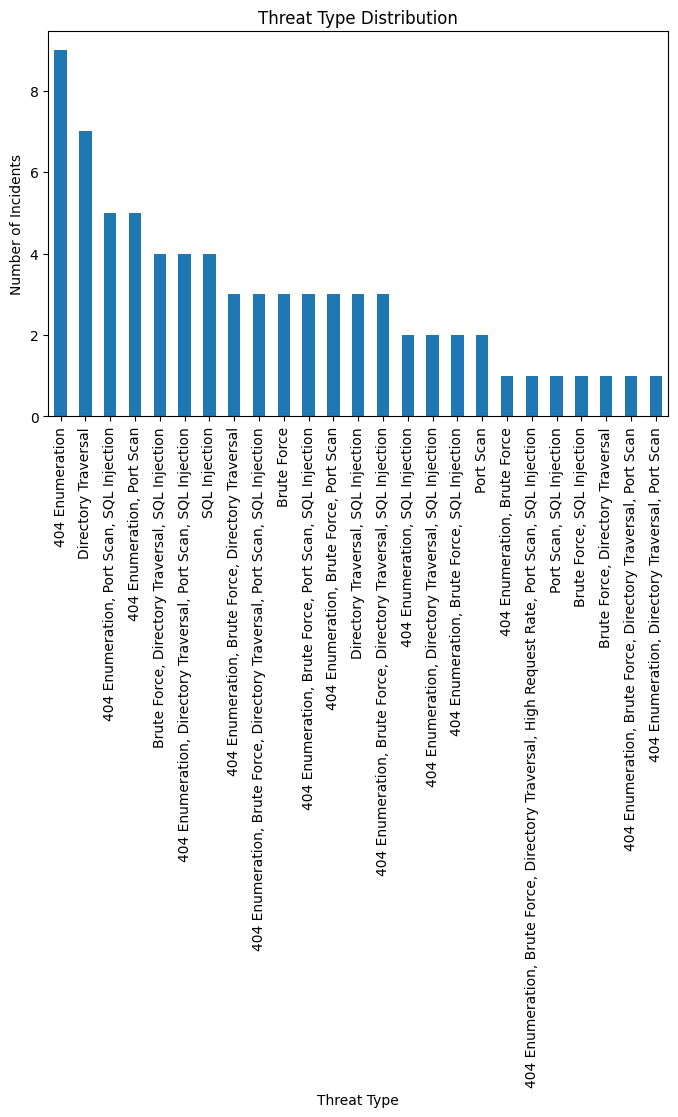

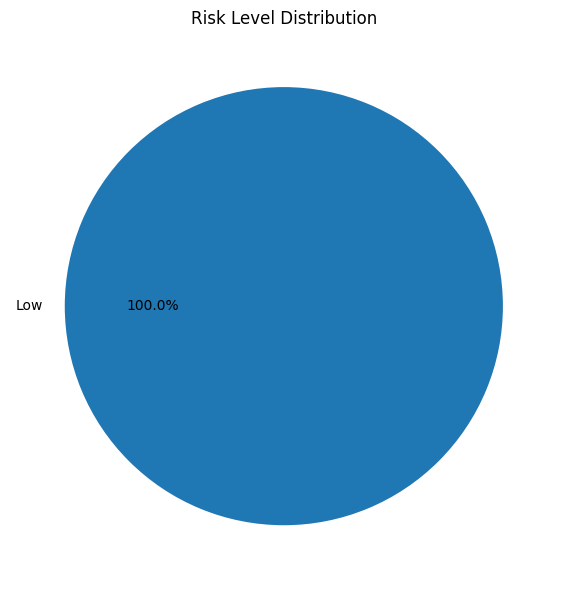

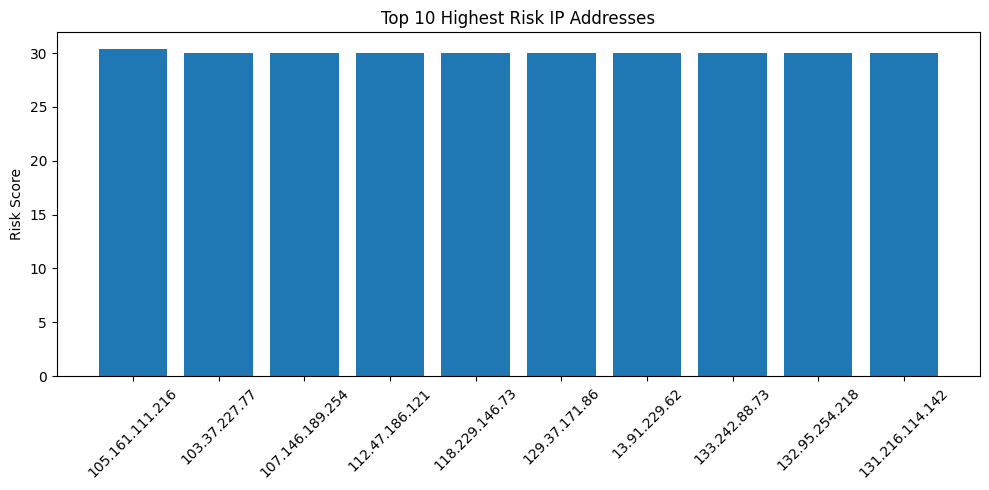

In [42]:
# ============================================================
# SECTION 15 - VISUALIZATION DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# -------------------------------
# Threat Types
# -------------------------------
plt.figure(figsize=(8,5))

threat_intelligence_df["threat_types"].value_counts().plot(kind="bar")

plt.title("Threat Type Distribution")
plt.xlabel("Threat Type")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

# -------------------------------
# Risk Levels
# -------------------------------
plt.figure(figsize=(6,6))

threat_intelligence_df["risk_level"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Risk Level Distribution")
plt.tight_layout()
plt.show()

# -------------------------------
# Top 10 Highest Risk IPs
# -------------------------------
plt.figure(figsize=(10,5))

top10 = threat_intelligence_df.nlargest(10, "risk_score")

plt.bar(top10["ip_address"], top10["risk_score"])

plt.xticks(rotation=45)

plt.title("Top 10 Highest Risk IP Addresses")

plt.ylabel("Risk Score")

plt.tight_layout()

plt.show()

In [43]:
# ============================================================
# SECTION 15 - FINAL INVESTIGATION REPORT
# ============================================================

final_report = threat_intelligence_df[[
    "ip_address",
    "threat_types",
    "highest_severity",
    "abuse_score",
    "vt_malicious",
    "risk_score",
    "risk_level"
]]

display(final_report.head(20))

,ip_address,threat_types,highest_severity,abuse_score,vt_malicious,risk_score,risk_level
1,105.161.111.216,"Brute Force, Directory Traversal, SQL Injection",High,1,0,30.4,Low
0,103.37.227.77,"404 Enumeration, Brute Force, Directory Traversal",High,0,0,30.0,Low
2,107.146.189.254,"404 Enumeration, SQL Injection",High,0,0,30.0,Low
4,112.47.186.121,Directory Traversal,High,0,0,30.0,Low
5,118.229.146.73,SQL Injection,High,0,0,30.0,Low
7,129.37.171.86,Directory Traversal,High,0,0,30.0,Low
8,13.91.229.62,"404 Enumeration, Brute Force, Directory Traver...",High,0,0,30.0,Low
12,133.242.88.73,"404 Enumeration, Brute Force, Directory Traversal",High,0,0,30.0,Low
11,132.95.254.218,"Brute Force, Directory Traversal, SQL Injection",High,0,0,30.0,Low
10,131.216.114.142,"404 Enumeration, Brute Force",High,0,0,30.0,Low


In [44]:
# ============================================================
# SECTION 15 - SAVE PROJECT OUTPUTS
# ============================================================

# Save CSV
final_report.to_csv(
    "final_threat_report.csv",
    index=False
)

# Save SQLite
final_report.to_sql(
    "final_threat_report",
    conn,
    if_exists="replace",
    index=False
)

print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("Generated Outputs")

print("✓ SQLite Database")
print("✓ Threat Intelligence Table")
print("✓ Incident Summary")
print("✓ Final Threat Report (CSV)")
print("✓ Security Dashboard")

print("="*60)

PROJECT COMPLETED SUCCESSFULLY
Generated Outputs
✓ SQLite Database
✓ Threat Intelligence Table
✓ Incident Summary
✓ Final Threat Report (CSV)
✓ Security Dashboard


In [83]:
# ============================================================
# SECTION 16 - PROJECT EVALUATION & CONCLUSION
# ============================================================

print("="*70)
print("PROJECT EVALUATION")
print("="*70)

print("\nDATASET SUMMARY")
print("-"*70)
print(f"Total Log Records       : {len(final_logs):,}")
print(f"Total Users             : {CONFIG['NUM_USERS']:,}")
print(f"Total Simulated Attackers : {CONFIG['NUM_ATTACKERS']:,}")

print("\nTHREAT DETECTION SUMMARY")
print("-"*70)
print(f"Detected Threat Events  : {len(detected_threats):,}")
print(f"Unique Incidents        : {len(incident_summary):,}")

print("\nThreat Distribution")
print(threat_statistics)

print("\nRisk Level Distribution")
print(
    threat_intelligence_df["risk_level"]
    .value_counts()
)

print("\nTop 5 Highest Risk IPs")
display(
    threat_intelligence_df[
        [
            "ip_address",
            "risk_score",
            "risk_level",
            "threat_types"
        ]
    ]
    .head(5)
)

print("\nPROJECT STATUS")
print("-"*70)
print("✓ Synthetic web server logs generated")
print("✓ SQLite database successfully created")
print("✓ Rule-based threat detection completed")
print("✓ Threat intelligence enrichment completed")
print("✓ Risk scoring completed")
print("✓ Security dashboard generated")
print("✓ Final investigation report exported")

print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

PROJECT EVALUATION

DATASET SUMMARY
----------------------------------------------------------------------
Total Log Records       : 135,096
Total Users             : 2,500
Total Simulated Attackers : 80

THREAT DETECTION SUMMARY
----------------------------------------------------------------------
Detected Threat Events  : 178
Unique Incidents        : 74

Threat Distribution
           threat_type  incidents events
0      404 Enumeration         48    931
1          Brute Force         29    480
2  Directory Traversal         33    445
3    High Request Rate          1    105
4            Port Scan         29    164
5        SQL Injection         38    579

Risk Level Distribution
risk_level
Low    74
Name: count, dtype: int64

Top 5 Highest Risk IPs


,ip_address,risk_score,risk_level,threat_types
1,105.161.111.216,30.4,Low,"Brute Force, Directory Traversal, SQL Injection"
0,103.37.227.77,30.0,Low,"404 Enumeration, Brute Force, Directory Traversal"
2,107.146.189.254,30.0,Low,"404 Enumeration, SQL Injection"
4,112.47.186.121,30.0,Low,Directory Traversal
5,118.229.146.73,30.0,Low,SQL Injection



PROJECT STATUS
----------------------------------------------------------------------
✓ Synthetic web server logs generated
✓ SQLite database successfully created
✓ Rule-based threat detection completed
✓ Threat intelligence enrichment completed
✓ Risk scoring completed
✓ Security dashboard generated
✓ Final investigation report exported
PROJECT COMPLETED SUCCESSFULLY
